In [1]:
from pathlib import Path
import zipfile

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

In [2]:
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Seed fixed:", SEED)

Seed fixed: 42


In [3]:
IMAGE_SIZE = 64
BATCH_SIZE = 32

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

In [4]:
dataset = datasets.ImageFolder(
    root="D:\\Deep Learning Course\\CNN\\data\\PetImages",
    transform=transform
)

print("Classes:", dataset.classes)
print("Total images:", len(dataset))

Classes: ['Cat', 'Dog']
Total images: 24998


In [5]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(SEED)
)

print("Training images:", len(train_dataset))
print("Testing images:", len(test_dataset))

Training images: 19998
Testing images: 5000


In [6]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using:", device)

Using: cpu


In [8]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # CNN layers
        self.cnn = nn.Sequential(

            # Input: 3 channels (RGB), output: 16 filters
            nn.Conv2d(
                in_channels=3,
                out_channels=16,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Input: 16 feature maps, output: 32 filters
            nn.Conv2d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Input: 32 feature maps, output: 64 filters
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Hidden layer and output layer
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),  # Hidden layer
            nn.ReLU(),
            nn.Linear(128, 1)             # Output: cat or dog
        )

    def forward(self, x):
        x = self.cnn(x)
        x = self.classifier(x)
        return x


model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (cnn): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)


In [9]:
loss_function = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [10]:
EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()

    correct = 0
    total = 0
    running_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = loss_function(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        predictions = (torch.sigmoid(outputs) >= 0.5).float()

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    accuracy = 100 * correct / total

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Loss: {running_loss:.4f} | "
        f"Training Accuracy: {accuracy:.2f}%"
    )

c:\Users\Mostafa Mohamed\AppData\Local\Programs\Python\Python311\Lib\site-packages\PIL\TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 1/10 | Loss: 406.4066 | Training Accuracy: 60.77%
Epoch 2/10 | Loss: 342.5124 | Training Accuracy: 72.01%
Epoch 3/10 | Loss: 303.6482 | Training Accuracy: 76.43%
Epoch 4/10 | Loss: 278.2402 | Training Accuracy: 78.90%
Epoch 5/10 | Loss: 254.9154 | Training Accuracy: 81.08%
Epoch 6/10 | Loss: 236.7192 | Training Accuracy: 82.68%
Epoch 7/10 | Loss: 220.1168 | Training Accuracy: 84.25%
Epoch 8/10 | Loss: 200.8807 | Training Accuracy: 85.81%
Epoch 9/10 | Loss: 178.4522 | Training Accuracy: 87.56%
Epoch 10/10 | Loss: 155.9175 | Training Accuracy: 89.35%


In [11]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        outputs = model(images)

        predictions = (torch.sigmoid(outputs) >= 0.5).float()

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

test_accuracy = 100 * correct / total

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 81.30%


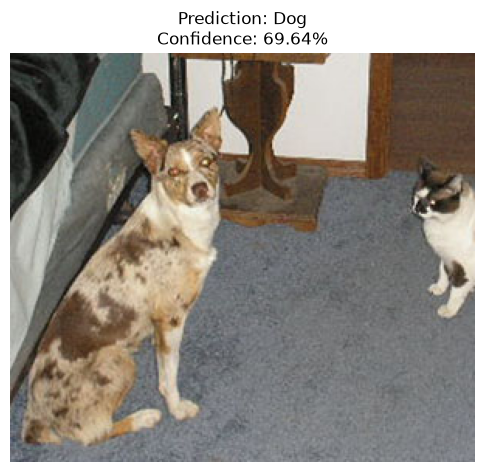

Selected image: D:/Deep Learning Course/CNN/data/PetImages/Dog/7.jpg
Prediction: Dog
Confidence: 69.64%


In [13]:
from tkinter import Tk, filedialog
from PIL import Image
import matplotlib.pyplot as plt

# Open a window to choose an image
root = Tk()
root.withdraw()
root.attributes("-topmost", True)

image_path = filedialog.askopenfilename(
    title="Choose a cat or dog image",
    filetypes=[
        ("Image files", "*.jpg *.jpeg *.png *.webp"),
        ("All files", "*.*")
    ]
)

root.destroy()

if image_path == "":
    print("No image selected.")
else:
    # Open image
    image = Image.open(image_path).convert("RGB")

    # Same preprocessing used during training
    image_tensor = transform(image).unsqueeze(0).to(device)

    # Prediction
    model.eval()

    with torch.no_grad():
        output = model(image_tensor)
        dog_probability = torch.sigmoid(output).item()

    if dog_probability >= 0.5:
        prediction = "Dog"
        confidence = dog_probability
    else:
        prediction = "Cat"
        confidence = 1 - dog_probability

    # Display result
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.title(f"Prediction: {prediction}\nConfidence: {confidence:.2%}")
    plt.axis("off")
    plt.show()

    print("Selected image:", image_path)
    print("Prediction:", prediction)
    print(f"Confidence: {confidence:.2%}")